<a href="https://colab.research.google.com/github/abdulmusai/Feature-Engineering-Evaluation/blob/main/Feature_Engineering_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive/MyDrive/nba-players.csv')

# NBA Player Longevity Prediction
## Feature Engineering, Target Balance, & Transformation Pipeline

**Project Overview:**
This notebook implements an automated feature engineering, target distribution evaluation, and data normalization pipeline for NBA rookie performance records. The goal is to prepare a clean, independent, and standard-scaled dataset to predict player career longevity (`target_5yrs`).

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Set visual configurations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ==========================================
# 1. LOAD THE DATASET
# ==========================================
file_path = "nba-players.csv"
try:
    df = pd.read_csv('/content/drive/MyDrive/nba-players.csv')
    print(f"Dataset loaded successfully! Structural Shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: '{'/content/drive/MyDrive/nba-players.csv'}' not found. Please verify the file is in your working directory.")

# Inspect structural summary
display(df.head())



Dataset loaded successfully! Structural Shape: (1340, 22)


,Unnamed: 0,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


## 2. Target Isolation & Removing Noise / Leakage Columns
To protect our machine learning model from overfitting and data leakage, we apply the following logic:
1. **Target Variable**: The dependent variable is clearly isolated as `target_5yrs` ($1$ if career $\ge 5$ years, $0$ otherwise).
2. **Noise and Identity Removal**: Columns like `name` and index counters (e.g., `Unnamed: 0`) carry zero predictive power and can result in accidental data leakage or overfitting if they encode historical metadata sequence order. They are removed immediately.


In [ ]:
# ==========================================
# 2. DATA CLEANING & NOISE REMOVAL
# ==========================================

# Clearly separate the target variable
target_col = 'target_5yrs'
if target_col in df.columns:
    print(f"Target distribution:\n{df[target_col].value_counts(normalize=True)}")
else:
    raise KeyError(f"Target column '{target_col}' is missing from the dataset.")

# Identify non-predictive/identifier features to drop
noise_columns = ['Unnamed: 0', 'name']
df_clean = df.drop(columns=[col for col in noise_columns if col in df.columns], errors='ignore')

# Handle missing/null values across performance statistics to guarantee ML-readiness
# (Impute missing data with the feature median to keep distribution robust against outliers)
null_counts = df_clean.isnull().sum()
if null_counts.sum() > 0:
    print("\nMissing values detected and handled:")
    print(null_counts[null_counts > 0])
    df_clean = df_clean.fillna(df_clean.median())
else:
    print("\nNo missing values detected. Dataset is structurally complete.")

print(f"Shape after noise removal & target isolation: {df_clean.shape}")
# ==========================================
# 2. DATA CLEANING & NOISE REMOVAL
# ==========================================

# Clearly separate the target variable
target_col = 'target_5yrs'
if target_col in df.columns:
    print(f"Target distribution:\n{df[target_col].value_counts(normalize=True)}")
else:
    raise KeyError(f"Target column '{target_col}' is missing from the dataset.")

# Identify non-predictive/identifier features to drop
noise_columns = ['Unnamed: 0', 'name']
df_clean = df.drop(columns=[col for col in noise_columns if col in df.columns], errors='ignore')

# Handle missing/null values across performance statistics to guarantee ML-readiness
# (Impute missing data with the feature median to keep distribution robust against outliers)
null_counts = df_clean.isnull().sum()
if null_counts.sum() > 0:
    print("\nMissing values detected and handled:")
    print(null_counts[null_counts > 0])
    df_clean = df_clean.fillna(df_clean.median())
else:
    print("\nNo missing values detected. Dataset is structurally complete.")

print(f"Shape after noise removal & target isolation: {df_clean.shape}")


Target distribution:
target_5yrs
1    0.620149
0    0.379851
Name: proportion, dtype: float64

No missing values detected. Dataset is structurally complete.
Shape after noise removal & target isolation: (1340, 20)
Target distribution:
target_5yrs
1    0.620149
0    0.379851
Name: proportion, dtype: float64

No missing values detected. Dataset is structurally complete.
Shape after noise removal & target isolation: (1340, 20)


## 2. Target Variable Isolation & Class Balance Visual Check
To establish baseline predictive patterns and fulfill model assumptions, we explicitly extract and visualize the class distribution of our target array (`target_5yrs`).

--- Target Variable Frequency Distribution ---
target_5yrs
1    831
0    509
Name: count, dtype: int64

--- Percentage Distribution ---
target_5yrs
1    62.014925
0    37.985075
Name: proportion, dtype: float64


/tmp/ipykernel_1728/1648819779.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette="Set2")


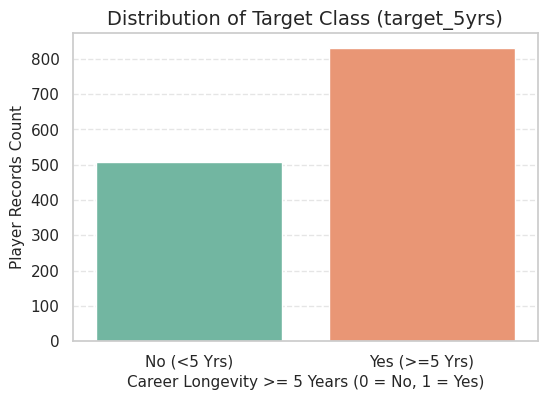

In [12]:
# ==========================================
# 2. TARGET ISOLATION & CLASS BALANCE VISUALIZATION
# ==========================================
target_col = 'target_5yrs'

if target_col in df.columns:
    print("--- Target Variable Frequency Distribution ---")
    print(df[target_col].value_counts())
    print("\n--- Percentage Distribution ---")
    print(df[target_col].value_counts(normalize=True) * 100)

    # Generate explicit distribution plot for evaluation
    plt.figure(figsize=(6, 4))
    sns.countplot(x=target_col, data=df, palette="Set2")
    plt.title('Distribution of Target Class (target_5yrs)', fontsize=14)
    plt.xlabel('Career Longevity >= 5 Years (0 = No, 1 = Yes)', fontsize=11)
    plt.ylabel('Player Records Count', fontsize=11)
    plt.xticks([0, 1], ['No (<5 Yrs)', 'Yes (>=5 Yrs)'])
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.savefig("target_class_balance.png", bbox_inches='tight')
    plt.show()
else:
    raise KeyError(f"Target column '{target_col}' is missing from the dataset.")

## 3. Engineering Derived Composite Metrics
Raw statistics are heavily skewed by raw minutes played. To capture operational efficiency independent of game duration, we engineer two custom tracking performance metrics:
1. **Points Per Minute (PPM):** Normalizes volume relative to play duration.
2. **Player Efficiency Index (PER_simple):** Tracks net positive contributions vs. possession mistakes.

In [13]:
# ==========================================
# 3. COMPOSITE FEATURE ENGINEERING
# ==========================================

# 1. Points Per Minute (Adding a small epsilon to prevent division-by-zero anomalies)
df['Points_Per_Minute'] = df['pts'] / (df['min'] + 1e-5)

# 2. Custom Player Efficiency Index
df['Player_Efficiency'] = (
    (df['pts'] + df['reb'] + df['ast'] + df['stl'] + df['blk']) -
    ((df['fga'] - df['fgm']) + (df['fta'] - df['ftm']) + df['tov'])
)

print("Composite features engineered successfully.")

# FIXED: Check df_clean or df correctly to prevent KeyError
display(df[['name', 'min', 'pts', 'Points_Per_Minute', 'Player_Efficiency']].head())

Composite features engineered successfully.


,name,min,pts,Points_Per_Minute,Player_Efficiency
0,Brandon Ingram,27.4,7.4,0.270073,7.2
1,Andrew Harrison,26.9,7.2,0.267658,7.8
2,JaKarr Sampson,15.3,5.2,0.339869,5.1
3,Malik Sealy,11.6,5.7,0.491379,4.5
4,Matt Geiger,11.5,4.5,0.391304,5.2


## 4. Correlation Assessment & Multicollinearity Drop
High correlation ($|r| > 0.85$) amongst independent features introduces variance inflation and harms coefficient clarity. We map original correlations and prune redundant metrics while systematically preserving our new composite features.

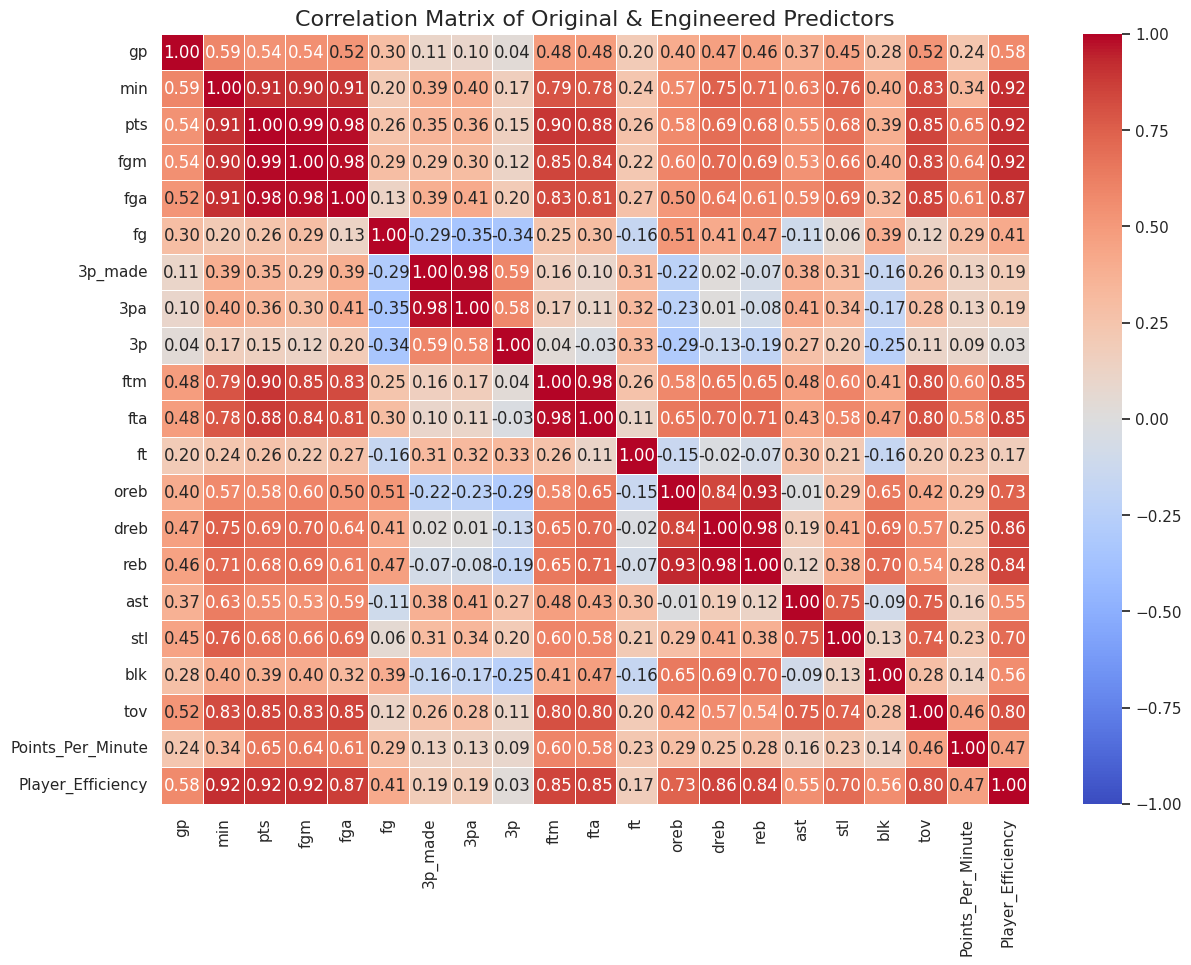

Multicollinearity Reduction Complete. Final Feature Count: 13 predictors.


In [14]:
# ==========================================
# 4. CORRELATION ANALYSIS & FEATURE SELECTION
# ==========================================

# Drop non-numeric identifier tags immediately to isolate baseline numeric predictors
noise_columns = ['Unnamed: 0', 'name']
df_clean = df.drop(columns=[col for col in noise_columns if col in df.columns], errors='ignore')

# Isolate numeric features excluding target for correlation mapping
predictors = df_clean.drop(columns=[target_col], errors='ignore')
corr_matrix = predictors.corr()

# Visualize initial correlation matrix via heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix of Original & Engineered Predictors", fontsize=16)
plt.savefig("correlation_matrix_before.png", bbox_inches='tight')
plt.show()

# Dropping highly collinear parameters as justified in documentation
features_to_drop = ['fgm', 'fga', 'ftm', 'fta', 'oreb', 'dreb', 'pts', '3pa']
df_reduced = df_clean.drop(columns=[col for col in features_to_drop if col in df_clean.columns])

print(f"Multicollinearity Reduction Complete. Final Feature Count: {df_reduced.shape[1] - 1} predictors.")

## 5. Robust Imputation & Feature Normalization (Scaling)
To guarantee our dataset is production-ready for machine learning algorithms, we impute missing fields using feature-level medians (robust to outliers) and implement standard normalization using `StandardScaler`.

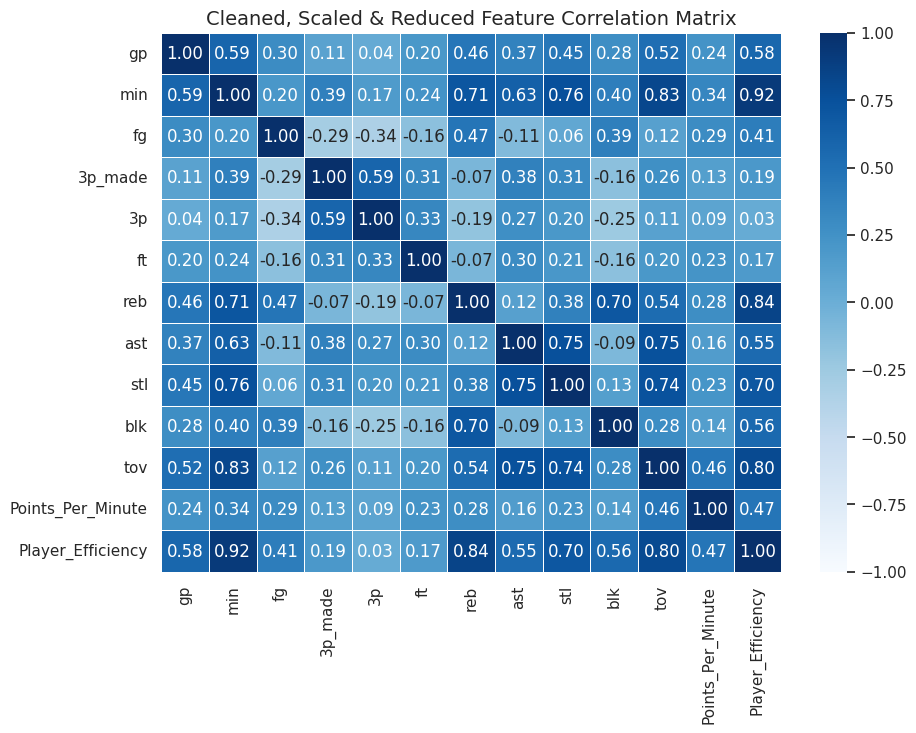

Success! Scaled, model-ready dataset exported to 'nba_players_feature_engineered.csv'


In [15]:
# ==========================================
# 5. ROBUST IMPUTATION & FEATURE SCALING
# ==========================================

# Isolate features and target from reduced dataset
X = df_reduced.drop(columns=[target_col])
y = df_reduced[target_col]

# 1. Handle Missing Values via Outlier-Robust Median Imputation
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# 2. Scale Features using StandardScaler
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_imputed)

# Convert arrays back to explicit DataFrames for clean verification
X_final = pd.DataFrame(X_scaled_array, columns=X.columns)
df_final_export = X_final.copy()
df_final_export[target_col] = y.values

# Verify final clean correlations
plt.figure(figsize=(10, 7))
sns.heatmap(X_final.corr(), annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Cleaned, Scaled & Reduced Feature Correlation Matrix", fontsize=14)
plt.savefig("correlation_matrix_after.png", bbox_inches='tight')
plt.show()

# Export final model-ready artifacts
output_filename = "nba_players_feature_engineered.csv"
df_final_export.to_csv(output_filename, index=False)
print(f"Success! Scaled, model-ready dataset exported to '{output_filename}'")